# Walkthrough — adaptive phase search under a fixed budget

What the model is, what each algorithm does with it, and where every reported number comes from.
Runs against the current package: `qmetrology/` for the algorithms, `results/*.csv` for the
reported numbers. Nothing here re-runs the production sweep.

    jupyter lab notebooks/walkthrough.ipynb


In [1]:
import os, sys, csv, collections
import numpy as np
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path[:0] = [ROOT, os.path.join(ROOT, "analysis")]

from qmetrology import algorithms as A, manifest as M
from qmetrology.sim import simulate_errors
from qmetrology.safeguard import pilot_sd, risk_optimal_depth
from qmetrology.trace import AlgorithmTrace, n_opt
from pipeline_io import path

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False})
print("results dir:", path(""))

results dir: /home/tsteindl/Programming/ba_thesis_sim/results/


## 1. The measurement

A maximally-entangled circuit with `N` phase gates reads out "0" with probability `cos²(Nφ)`.
Drawing `m` shots and inverting gives the estimator

    φ̂ = arccos(√(hits/m)) / N

which is only valid while `Nφ < π/2`. Past that the `arccos` folds and the estimate collapses
*toward zero* — it does not merely get noisy. The largest safe depth is `N_opt = ⌊π/2φ⌋`.

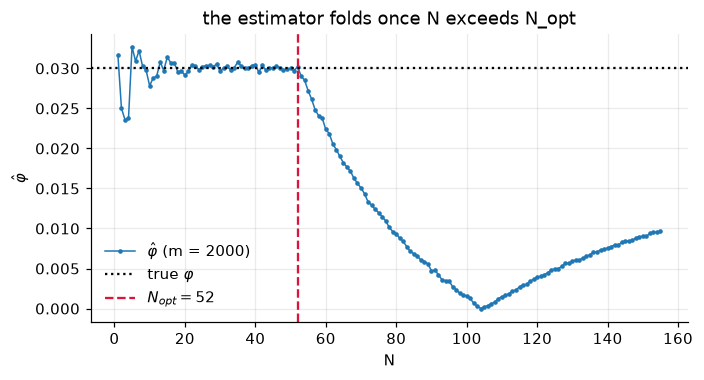

In [2]:
phi = 0.03
n_opt_true = n_opt(phi)
Ns = np.arange(1, 3 * n_opt_true)
rng = np.random.default_rng(0)
est = np.array([simulate_errors(rng, phi, 2000, int(N)) for N in Ns])

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(Ns, est, ".-", lw=1, ms=4, label=r"$\hat\varphi$ (m = 2000)")
ax.axhline(phi, color="k", ls=":", label=r"true $\varphi$")
ax.axvline(n_opt_true, color="crimson", ls="--", label=rf"$N_{{opt}} = {n_opt_true}$")
ax.set(xlabel="N", ylabel=r"$\hat\varphi$", title="the estimator folds once N exceeds N_opt")
ax.legend()
plt.show()

The variance below the boundary is `1/(4 N² m)` — independent of φ. So for a *fixed*
budget `C = N·m` the standard deviation is `1/(2N√m) = 1/(2√(N·C))`: deeper is better, right up to
the cliff. That single trade-off is what every algorithm here is negotiating.

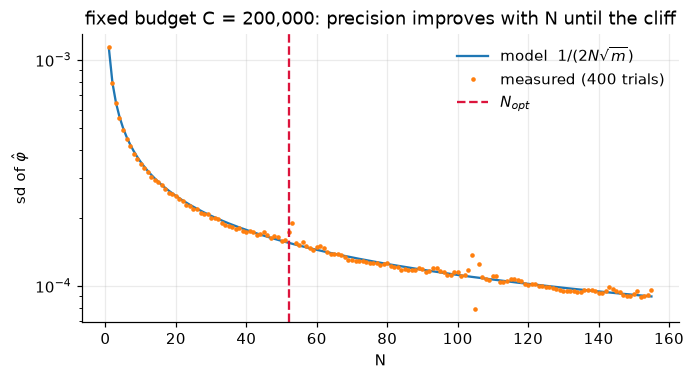

In [3]:
C = 200_000
sd_model = np.array([1 / (2 * N * np.sqrt(C // N)) for N in Ns])
sd_meas = np.array([np.std([simulate_errors(np.random.default_rng(s), phi, C // int(N), int(N))
                            for s in range(400)]) for N in Ns])

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(Ns, sd_model, label=r"model  $1/(2N\sqrt{m})$")
ax.plot(Ns, sd_meas, ".", ms=4, label="measured (400 trials)")
ax.axvline(n_opt_true, color="crimson", ls="--", label=r"$N_{opt}$")
ax.set(yscale="log", xlabel="N", ylabel=r"sd of $\hat\varphi$",
       title=f"fixed budget C = {C:,}: precision improves with N until the cliff")
ax.legend()
plt.show()

## 2. The algorithms

All four share the signature `find_phi_*(rng, phi, phi_max, phi_min, ..., budget)` and return
`(φ̂, budget_used)`. Passing a `trace=` collector records what the algorithm did; the collector
draws no random numbers, so tracing never changes the result.

In [4]:
scen = next(s for s in M.SCENARIOS if s["id"] == "narrow_e3")
B, eps = 10_000, scen["eps"]
pmin, pmax = scen["phi_min"], scen["phi_max"]
print(f"{scen['label']}   N_min={M.n_min_of(scen)}  N_max={M.n_max_of(scen)}")

runs = {
    "brute":       lambda r, p, t: A.find_phi_fixed_budget_brute_force(r, p, pmax, pmin, B, trace=t),
    "linear":      lambda r, p, t: A.find_phi_fixed_budget_linear_search(
                        r, p, pmax, pmin, 120, B, lookback_window=3, safeguard=1, trace=t),
    "binary_deep": lambda r, p, t: A.find_phi_fixed_budget_binary_search_deep(
                        r, p, pmax, pmin, 120, B, eps_target=eps, conf=0.5, trace=t),
    "reverse_eng": lambda r, p, t: A.find_phi_fixed_budget_reverse_engineering_risk(
                        r, p, pmax, pmin, 120, B, eps_target=eps, trace=t),
}

phi_demo = 0.02
for name, fn in runs.items():
    tr = AlgorithmTrace(algorithm=name)
    phi_hat, used = fn(np.random.default_rng(7), phi_demo, tr)
    print(f"{name:12s} phi_hat={phi_hat:.5f}  err={abs(phi_hat-phi_demo):.2e}  spent={used:,}/{B:,}"
          f"  probes={len(tr.probes):2d}  N_guess={tr.N_guess}  N_star={tr.N_star}"
          f"  (N_opt={n_opt(phi_demo)})")

U(0.01,0.1), eps=1e-03   N_min=15  N_max=157
brute        phi_hat=0.02118  err=1.18e-03  spent=9,990.0/10,000  probes= 0  N_guess=None  N_star=15  (N_opt=78)
linear       phi_hat=0.01877  err=1.23e-03  spent=9,994.0/10,000  probes= 4  N_guess=18  N_star=17  (N_opt=78)
binary_deep  phi_hat=0.01912  err=8.81e-04  spent=9,978.0/10,000  probes= 1  N_guess=15  N_star=58  (N_opt=78)
reverse_eng  phi_hat=0.01912  err=8.81e-04  spent=9,978.0/10,000  probes= 1  N_guess=76  N_star=58  (N_opt=78)


### What the exploration phase actually does

Linear search scans `N` upward until the running mean of its estimates falls `lookback_window`
times in a row, then backs off. Binary search bisects `[N_min, N_max]`, classifying a probe as an
overshoot when its estimate drops below a normal-quantile threshold. Reverse engineering takes one
cheap pilot at `N_min` and infers the depth directly.

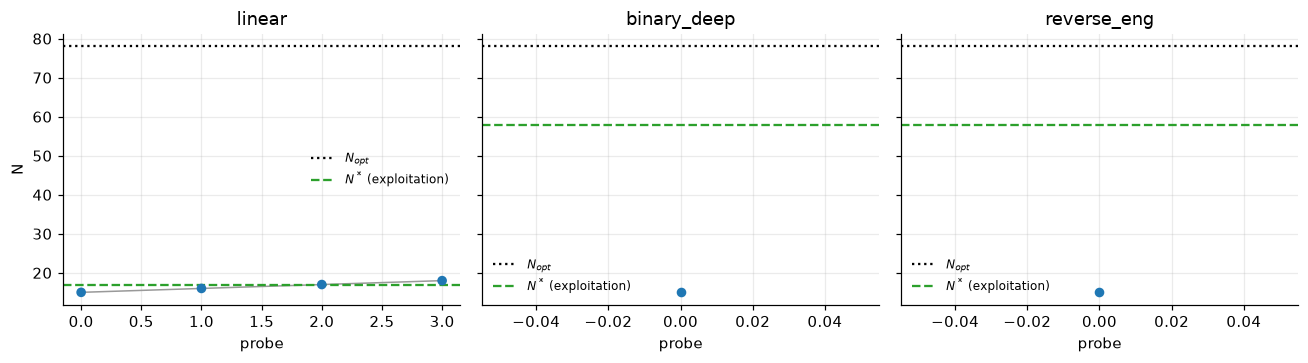

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, name in zip(axes, ["linear", "binary_deep", "reverse_eng"]):
    tr = AlgorithmTrace(algorithm=name)
    runs[name](np.random.default_rng(7), phi_demo, tr)
    Np = [p.N for p in tr.probes]
    ok = [not p.declared_overshoot for p in tr.probes]
    ax.plot(range(len(Np)), Np, "-", color="0.6", lw=1)
    ax.scatter(range(len(Np)), Np, c=["tab:blue" if o else "tab:red" for o in ok], s=28, zorder=3)
    ax.axhline(n_opt(phi_demo), color="k", ls=":", label=r"$N_{opt}$")
    if tr.N_star:
        ax.axhline(tr.N_star, color="tab:green", ls="--", label=r"$N^*$ (exploitation)")
    ax.set(title=name, xlabel="probe")
    ax.legend(fontsize=8)
axes[0].set_ylabel("N")
plt.tight_layout(); plt.show()

## 3. The statistical safeguard

The exploration produces a pilot `(φ̂ₚ, Nₚ)` with sd `σₚ = 1/(2Nₚ√mₚ)`. The safeguard picks the
exploitation depth by enumerating **every** integer in `[N_min, N_max]` and maximising

    P(N is not aliased | pilot) × P(the estimate resolves ε at m = ⌊B/N⌋ shots)

The first factor comes from the truncated-normal posterior over the prior support, the second from
the asymptotic law. It replaces the tuned constants the published algorithms used
(`docs/SAFEGUARD_DERIVATION.md`).

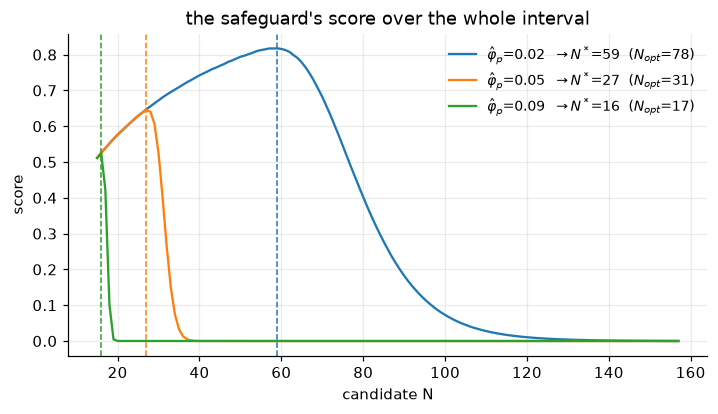

In [6]:
from qmetrology.safeguard import _score, _p_safe

N_min, N_max = M.n_min_of(scen), M.n_max_of(scen)
m_pilot, B_rem = 120, 8_000
cand = np.arange(N_min, N_max + 1)

fig, ax = plt.subplots(figsize=(7.5, 3.8))
for phi_hat in (0.02, 0.05, 0.09):
    sd = pilot_sd(N_min, m_pilot)
    sc = _score(cand, phi_hat, sd, B_rem, eps, (pmin, pmax))
    pick = risk_optimal_depth(phi_hat, sd, B_rem, eps, N_min=N_min, N_max=N_max,
                              support=(pmin, pmax))
    l, = ax.plot(cand, sc, label=rf"$\hat\varphi_p$={phi_hat}  $\to N^*$={pick}"
                                rf"  ($N_{{opt}}$={n_opt(phi_hat)})")
    ax.axvline(pick, color=l.get_color(), ls="--", lw=1)
ax.set(xlabel="candidate N", ylabel="score", title="the safeguard's score over the whole interval")
ax.legend(fontsize=9)
plt.show()

## 4. The reported numbers

Everything below is read from `results/`, produced by `python analysis/run.py --max`. Nothing is
recomputed here, so these are exactly the values the thesis quotes.

In [7]:
def read(name):
    with open(path(name), newline="") as f:
        return list(csv.DictReader(f))

perf, cross = read("performance_curves.csv"), read("budget_crossings.csv")
LABEL = {"brute": "Brute force", "linear": "Linear search", "binary_deep": "Binary search",
         "reverse_eng_risk": "Reverse engineering", "separable": "Separable (N=1)",
         "oracle_hl": "Oracle ceiling"}

print("Fixed budget 10,000, phi ~ U(0.01,0.1), eps = 1e-3\n")
for r in perf:
    if r["scenario_id"] == "narrow_e3" and r["budget"] == "10000":
        # the oracle is analytic: one deterministic rate, so it carries no interval
        ci = (f"[{100*float(r['rate_lo']):.1f}, {100*float(r['rate_hi']):.1f}]"
              if r["rate_lo"] else "analytic")
        print(f"  {LABEL[r['algorithm']]:22s} {100*float(r['rate']):5.1f}%   {ci}")

Fixed budget 10,000, phi ~ U(0.01,0.1), eps = 1e-3

  Binary search           65.1%   [64.7, 65.5]
  Brute force             56.1%   [55.7, 56.5]
  Linear search           64.1%   [63.7, 64.5]
  Reverse engineering     66.3%   [65.8, 66.7]
  Separable (N=1)         15.7%   [15.4, 16.0]
  Oracle ceiling          73.5%   analytic


In [8]:
print("Budget to reach 90% convergence, ratio vs brute force\n")
eps_of = {s["id"]: s["eps"] for s in M.SCENARIOS}
narrow = [f"narrow_e{k}" for k in range(3, 9)]
print("  " + " " * 22 + "".join(f"{eps_of[s]:>12.0e}" for s in narrow))
for algo in ["linear", "binary_deep", "reverse_eng_risk"]:
    row = ""
    for s in narrow:
        m = [r for r in cross if r["scenario_id"] == s and r["algorithm"] == algo
             and r["threshold_pct"] == "90"]
        row += f"{'x' + m[0]['ratio_vs_brute'] if m and m[0]['ratio_vs_brute'] else '-':>12}"
    print(f"  {LABEL[algo]:22s}{row}")

Budget to reach 90% convergence, ratio vs brute force

                               1e-03       1e-04       1e-05       1e-06       1e-07       1e-08
  Linear search                x1.29       x1.56       x1.64       x1.65       x1.67       x1.66
  Binary search                x1.42        x1.6       x1.75       x1.78       x1.79       x1.77
  Reverse engineering          x1.54       x1.74        x1.8        x1.8       x1.81       x1.82


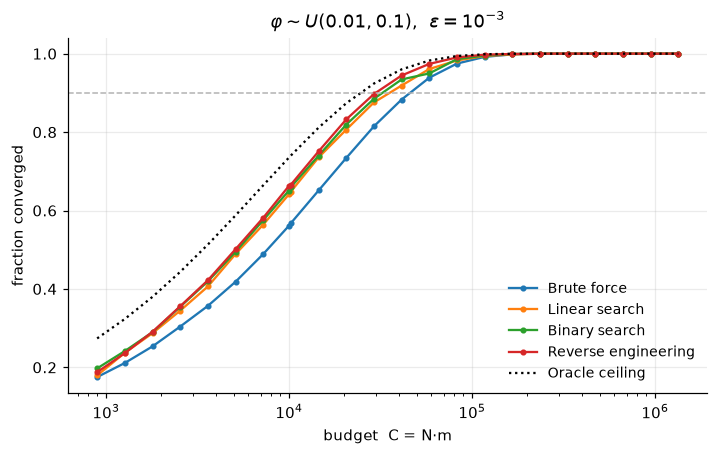

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for algo in ["brute", "linear", "binary_deep", "reverse_eng_risk", "oracle_hl"]:
    pts = sorted((int(r["budget"]), float(r["rate"])) for r in perf
                 if r["scenario_id"] == "narrow_e3" and r["algorithm"] == algo)
    ax.plot(*zip(*pts), "o-" if algo != "oracle_hl" else ":", ms=3,
            color="k" if algo == "oracle_hl" else None, label=LABEL[algo])
ax.axhline(0.9, color="0.7", lw=1, ls="--")
ax.set(xscale="log", xlabel="budget  C = N·m", ylabel="fraction converged",
       title=r"$\varphi \sim U(0.01, 0.1)$,  $\varepsilon = 10^{-3}$")
ax.legend(fontsize=9)
plt.show()

## 5. Where the adaptive advantage comes from

The advantage is largest for *small* φ, where brute force's fixed `N_min = ⌊π/2φ_max⌋` is most
conservative: an algorithm that discovers φ is small can go much deeper. The per-phase diagnostics
show this directly.

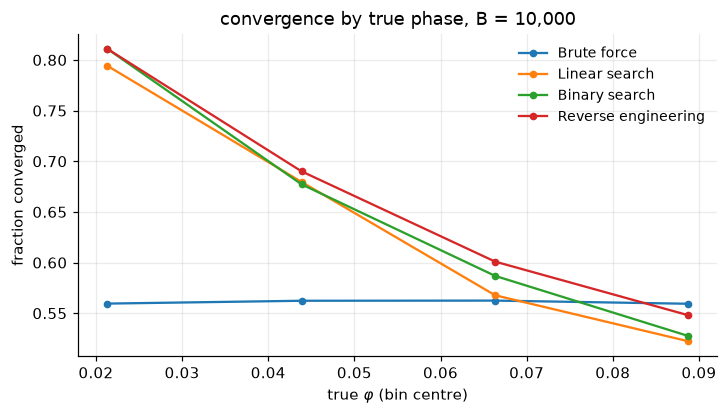

In [10]:
phase = read("diagnostics_by_phase.csv")
rows = [r for r in phase if r["scenario_id"] == "narrow_e3" and int(float(r["budget"])) == 10_000]
by = collections.defaultdict(list)
for r in rows:
    if r["algorithm"] in LABEL and r["rate"]:
        by[r["algorithm"]].append((0.5 * (float(r["phi_lo"]) + float(r["phi_hi"])), float(r["rate"])))
assert by, "no phase-stratified rows found -- check the scenario/budget filter"

fig, ax = plt.subplots(figsize=(7.5, 3.8))
for algo in ["brute", "linear", "binary_deep", "reverse_eng_risk"]:
    if by[algo]:
        ax.plot(*zip(*sorted(by[algo])), "o-", ms=4, label=LABEL[algo])
ax.set(xlabel=r"true $\varphi$ (bin centre)", ylabel="fraction converged",
       title="convergence by true phase, B = 10,000")
ax.legend(fontsize=9)
plt.show()

## Where to go next

- `results/FULL_RESULTS.md` — the complete record, including the statistical methodology
- `docs/SAFEGUARD_DERIVATION.md` — the safeguard, its assumptions, and what each one buys
- `notebooks/safeguard_playground.ipynb` — change the safeguard and see what it does
- `python analysis/run.py --quick` — the whole pipeline in ~2 minutes